# Citation quality by disease category (Llama 4)

Two preregistered **descriptive** analyses at the **question** level with **95 % bootstrap CIs**:

- **Citation precision** = proportion of a question's cited docs a physician rated *supports*.
- **Citation support rate** = proportion of questions with **≥ 1** citation rated *supports*.

**Data** — `results/reader_study/responses.csv`, one row per *(physician × question)*.
Per question (240 questions, each rated by 1–3 physicians): `precision_q` = mean over raters of
`n_support / n_support_rated`; `supported_q` = majority of raters found ≥ 1 supporting doc
(`support_frac ≥ 0.5`). Bootstrap resamples **questions** (the preregistered unit); pass
`cluster=q["case_index"]` to resample the 16 **cases** instead.

Forest plots: point = subgroup mean, whisker = 95 % bootstrap CI, dashed line + shaded band =
overall estimate and its CI. Ordered by estimate; n shown per row.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

RESP = "../results/reader_study/responses.csv"
OUTDIR = "../plots/reader_study"
os.makedirs(OUTDIR, exist_ok=True)

# ---- palette (matches the study's other forest/dumbbell plots: seaborn "deep") ----
BLUE, INK, INK2, MUTED, GRID, SURFACE = "#4C72B0", "#2b2b2b", "#555555", "#888888", "#dddddd", "white"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "font.size": 12, "axes.labelsize": 13,
    "axes.edgecolor": "#b0b0b0", "axes.linewidth": 1.0,
    "xtick.color": INK2, "ytick.color": INK, "axes.labelcolor": INK, "text.color": INK,
    "savefig.dpi": 300, "savefig.bbox": "tight",
})

def despine(ax, left=True, bottom=True):
    for s, on in [("top", False), ("right", False), ("left", left), ("bottom", bottom)]:
        ax.spines[s].set_visible(on)


In [2]:
# ---------- load & aggregate to question level ----------
r = pd.read_csv(RESP)
r["precision"] = r["n_support"] / r["n_support_rated"]
q = r.groupby("question_id").agg(
    precision=("precision", "mean"),
    support_frac=("any_source_supports", "mean"),
    case_index=("case_index", "first"),
    disease_category=("disease_category", "first"),
).reset_index()
q["supported"] = (q["support_frac"] >= 0.5).astype(int)
print(f"{len(q)} questions | {q.case_index.nunique()} cases")


256 questions | 16 cases


In [3]:
# ---------- bootstrap CI helper ----------
def bootstrap_ci(values, stat=np.mean, B=10000, seed=0, alpha=0.05, cluster=None):
    # Percentile bootstrap. If `cluster` (array aligned to values) is given,
    # resample whole clusters (e.g. cases) instead of individual questions.
    rng = np.random.default_rng(seed)
    v = np.asarray(values, float)
    if cluster is None:
        idx = rng.integers(0, len(v), size=(B, len(v)))
        boots = stat(v[idx], axis=1)
    else:
        cl = np.asarray(cluster)
        groups = [np.where(cl == g)[0] for g in np.unique(cl)]
        G = len(groups); boots = np.empty(B)
        for b in range(B):
            sel = np.concatenate([groups[i] for i in rng.integers(0, G, size=G)])
            boots[b] = stat(v[sel])
    lo, hi = np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])
    return float(stat(v)), float(lo), float(hi)


In [4]:
def disease_forest(dfq, value, xlabel, outfile, min_n=8):
    rows = []
    for g, sub in dfq.groupby("disease_category"):
        if len(sub) < min_n:
            continue
        m, lo, hi = bootstrap_ci(sub[value].values)
        rows.append((g, m, lo, hi, len(sub)))
    rows.sort(key=lambda t: t[1])                 # highest at top
    ov, ovlo, ovhi = bootstrap_ci(dfq[value].values)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.axvspan(ovlo, ovhi, color=BLUE, alpha=0.08, zorder=0)
    ax.axvline(ov, color=MUTED, lw=1.2, ls="--", zorder=1)
    y = np.arange(len(rows))
    for i, (g, m, lo, hi, n) in enumerate(rows):
        ax.plot([lo, hi], [i, i], color=INK2, lw=2, solid_capstyle="round", zorder=3)
        ax.scatter([m], [i], s=95, color=BLUE, zorder=4, edgecolor="white", linewidth=1.0)
        ax.text(hi + 0.008, i, f"{m*100:.0f}", va="center", fontsize=11, color=BLUE)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{g}\n(n={n})" for g, *_, n in rows], fontsize=11.5)
    ax.set_ylim(-0.6, len(rows) - 0.4)
    ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0, decimals=0))
    ax.grid(axis="x", color=GRID, lw=0.9, zorder=0)
    despine(ax, left=False)
    ax.set_xlabel(xlabel)
    # explanatory caption below the axis (keeps the plot area clean, like the reference)
    fig.text(0.5, -0.02,
             f"Point = mean, bar = 95% bootstrap CI; dashed line = overall "
             f"({ov*100:.0f}%, [{ovlo*100:.0f}, {ovhi*100:.0f}]).  Categories with n < 8 omitted.",
             ha="center", fontsize=9.5, color=MUTED)
    fig.tight_layout()
    fig.savefig(f"{OUTDIR}/{outfile}")
    plt.show()


## Citation precision by disease category

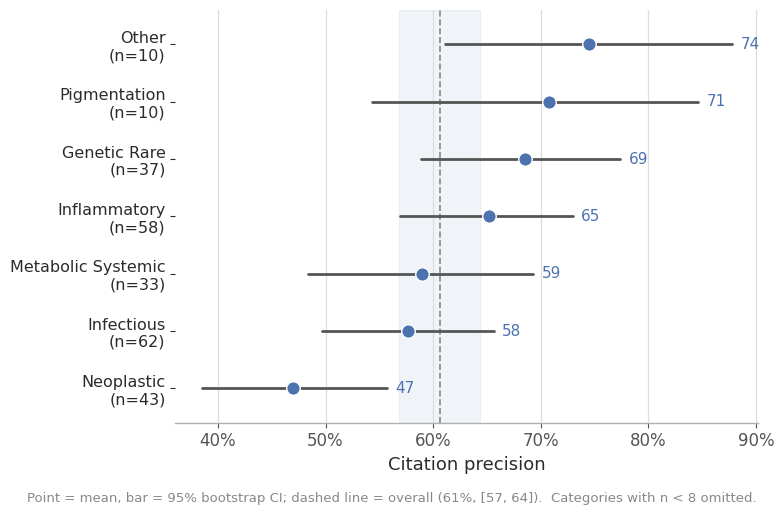

In [5]:
disease_forest(
    q, "precision",
    xlabel="Citation precision",
    outfile="citation_precision_by_disease.png",
)

## Citation support rate by disease category

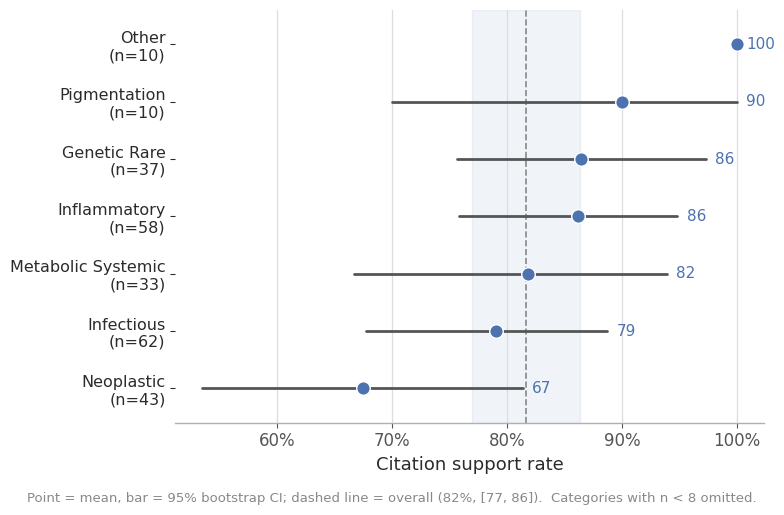

In [6]:
disease_forest(
    q, "supported",
    xlabel="Citation support rate",
    outfile="citation_support_rate_by_disease.png",
)

**Notes** — Subgroups with n < 8 are dropped. For case-clustered CIs, pass
`cluster=sub["case_index"]` / `cluster=q["case_index"]` to `bootstrap_ci`. Support rate binarizes
each question with majority rule (`support_frac ≥ 0.5`); swap `value="support_frac"` for the
continuous rater-agreement version.